In [4]:
# Combine multiple signals into a final risk score

import pandas as pd
import numpy as np
import os

# Load all saved data
data_path = os.path.expanduser("~/Desktop/SentriVaR-500/data")

prices    = pd.read_csv(f"{data_path}/prices.csv", index_col="Date", parse_dates=True)
macro     = pd.read_csv(f"{data_path}/macro_daily.csv", index_col="DATE", parse_dates=True)
risk      = pd.read_csv(f"{data_path}/risk_metrics.csv", index_col=0)
sentiment = pd.read_csv(f"{data_path}/sentiment_scores.csv")
regime    = pd.read_csv(f"{data_path}/regime_states.csv", parse_dates=["date"])

returns = prices.pct_change().dropna()

print("All data loaded")
print(f"  Prices:    {prices.shape}")
print(f"  Macro:     {macro.shape}")
print(f"  Risk:      {risk.shape}")
print(f"  Sentiment: {sentiment.shape}")
print(f"  Regime:    {regime.shape}")

All data loaded
  Prices:    (2141, 5)
  Macro:     (2126, 2)
  Risk:      (5, 4)
  Sentiment: (5, 3)
  Regime:    (2105, 3)


In [5]:
# Merge everything by date
regime = regime.set_index("date")

# Combine prices + macro + regime
combined = returns.join(macro, how="inner")
combined = combined.join(regime[["regime", "regime_label"]], how="inner")
combined = combined.dropna()

print(f"Combined data: {combined.shape}")
print(f"Date range: {combined.index[0].date()} ~ {combined.index[-1].date()}")
combined.tail()

Combined data: (2105, 9)
Date range: 2018-01-31 ~ 2026-07-09


,AAPL,GOOGL,JPM,MSFT,SOXX,VIX,Spread,regime,regime_label
Date,,,,,,,,,
2026-07-02,0.048407,-0.003599,0.001197,0.016160,-0.055661,16.15,0.35,1,Elevated
2026-07-06,0.013058,0.018199,0.014266,-0.009603,0.026822,15.57,0.35,1,Elevated
2026-07-07,-0.006397,0.001555,0.004442,0.005430,-0.051280,16.13,0.36,1,Elevated
2026-07-08,0.008788,-0.013923,-0.025352,-0.014145,0.018742,16.90,0.35,1,Elevated
2026-07-09,0.009030,-0.008372,0.014669,0.002661,0.034998,15.84,0.38,1,Elevated


In [6]:
# Core: risk score with regime-dependent weighting
def calculate_risk_score(row, sentiment_today):
    """
    Weight each signal differently depending on regime.
    - 0 (Normal)   → sentiment-weighted
    - 1 (Elevated) → balanced
    - 2 (Crisis)   → VIX + volatility-weighted
    """
    regime = row["regime"]

    # Average portfolio volatility (across 4 tickers)
    port_vol = abs(row[["AAPL", "GOOGL", "JPM", "MSFT"]].mean())

    # Normalize VIX to 0-1
    vix_norm = min(row["VIX"] / 80, 1.0)

    # Normalize sentiment (-1 to +1 → 0 to 1, higher = more negative)
    sentiment_norm = (1 - sentiment_today) / 2

    # Treasury spread risk (inverted spread = risky)
    spread_risk = 1 if row["Spread"] < 0 else 0

    # Regime-dependent weights
    if regime == 0:    # Normal
        weights = {"sentiment": 0.40, "vix": 0.25, "vol": 0.25, "spread": 0.10}
    elif regime == 1:  # Elevated
        weights = {"sentiment": 0.25, "vix": 0.35, "vol": 0.25, "spread": 0.15}
    else:              # Crisis
        weights = {"sentiment": 0.15, "vix": 0.45, "vol": 0.30, "spread": 0.10}

    score = (
        weights["sentiment"] * sentiment_norm +
        weights["vix"]       * vix_norm +
        weights["vol"]       * port_vol * 10 +
        weights["spread"]    * spread_risk
    )
    return round(min(score, 1.0), 4)

# Today's average sentiment score
sentiment_today = sentiment["sentiment_score"].mean()
print(f"Today's average sentiment: {sentiment_today:.4f}")

# Calculate risk score across the full period
combined["risk_score"] = combined.apply(
    lambda row: calculate_risk_score(row, sentiment_today), axis=1
)

print(f"\nRisk score stats:")
print(combined["risk_score"].describe().round(4))

Today's average sentiment: -0.1073

Risk score stats:
count    2105.0000
mean        0.3048
std         0.0751
min         0.1843
25%         0.2448
50%         0.2865
75%         0.3692
max         0.9396
Name: risk_score, dtype: float64


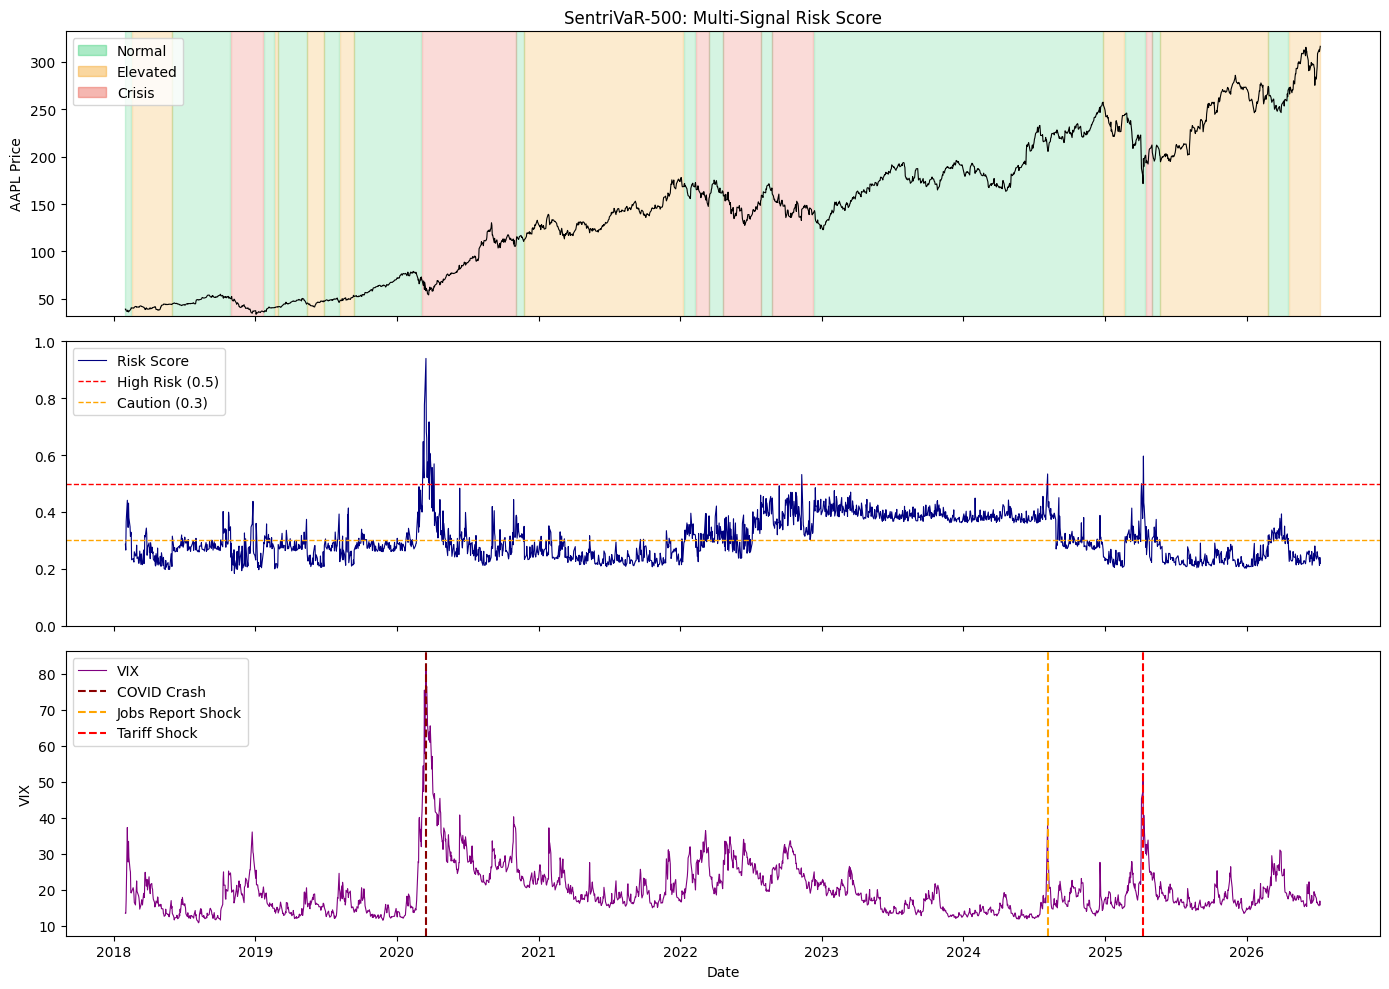

Saved: risk_score_final.png


In [7]:
# Visualize risk score by regime
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

colors_map = {0: "#2ecc71", 1: "#f39c12", 2: "#e74c3c"}
labels_map = {0: "Normal", 1: "Elevated", 2: "Crisis"}

# Price
ax1.plot(combined.index, prices["AAPL"].reindex(combined.index),
         color="black", linewidth=0.8)
ax1.set_ylabel("AAPL Price")
ax1.set_title("SentriVaR-500: Multi-Signal Risk Score")

# Regime background
y_min = prices["AAPL"].reindex(combined.index).min() * 0.95
y_max = prices["AAPL"].reindex(combined.index).max() * 1.05
for state, color in colors_map.items():
    mask = combined["regime"] == state
    ax1.fill_between(combined.index, y_min, y_max,
                     where=mask.values, alpha=0.2, color=color)
ax1.set_ylim(y_min, y_max)

# Legend
patches = [mpatches.Patch(color=c, alpha=0.4, label=labels_map[s])
           for s, c in colors_map.items()]
ax1.legend(handles=patches, loc="upper left")

# Risk score
ax2.plot(combined.index, combined["risk_score"],
         color="navy", linewidth=0.8, label="Risk Score")
ax2.axhline(0.5, color="red", linestyle="--", linewidth=1, label="High Risk (0.5)")
ax2.axhline(0.3, color="orange", linestyle="--", linewidth=1, label="Caution (0.3)")
ax2.set_ylim(0, 1)
ax2.legend(loc="upper left")

# VIX
ax3.plot(combined.index, combined["VIX"],
         color="purple", linewidth=0.8, label="VIX")
ax3.axvline(pd.Timestamp("2020-03-16"), color="darkred",
            linestyle="--", linewidth=1.5, label="COVID Crash")
ax3.axvline(pd.Timestamp("2024-08-05"), color="orange",
            linestyle="--", linewidth=1.5, label="Jobs Report Shock")
ax3.axvline(pd.Timestamp("2025-04-07"), color="red",
            linestyle="--", linewidth=1.5, label="Tariff Shock")
ax3.set_ylabel("VIX")
ax3.set_xlabel("Date")
ax3.legend(loc="upper left")

plt.tight_layout()
plt.savefig(f"{data_path}/risk_score_final.png", dpi=150)
plt.show()
print("Saved: risk_score_final.png")

In [8]:
# Save final risk scores
combined[["regime", "regime_label", "VIX", "Spread", "risk_score"]].to_csv(
    f"{data_path}/final_risk_scores.csv"
)
print("Saved: final_risk_scores.csv")

print(f"\nCurrent risk score: {combined['risk_score'].iloc[-1]:.4f}")
print(f"Current regime: {combined['regime_label'].iloc[-1]}")

Saved: final_risk_scores.csv

Current risk score: 0.2190
Current regime: Elevated
